In [1]:
import pandas as pd
df = pd.read_csv('rolling_results_all_feature.csv')


In [2]:
df = df[:-1]
df

,Unnamed: 0,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
0,0,2012_2013,[2014],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9501,0.465147,0.908117,0.921031,0.895560,0.061341,944555,519970
1,1,2013_2014,[2015],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9197,0.678842,0.899291,0.971538,0.837045,0.251232,1041192,530021
2,2,2014_2015,[2016],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9476,0.577973,0.917841,0.966588,0.873774,0.030201,1049991,524543
3,3,2015_2016,[2017],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9157,0.643234,0.888634,0.969517,0.820208,0.083148,1054564,468913
4,4,2016_2017,[2018],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9651,0.567357,0.902243,0.963378,0.848404,0.022265,993456,491374
5,5,2017_2018,[2019],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9724,0.585305,0.934694,0.937794,0.931615,-0.036056,960287,497246
6,6,2018_2019,[2020],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9789,0.511503,0.941712,0.945000,0.938446,-0.016463,988620,524057
7,7,2019_2020,[2021],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9687,0.548162,0.942985,0.981652,0.907249,0.006321,1021303,509384
8,8,2020_2021,[2022],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8890,0.752954,0.817967,0.868005,0.773385,0.341546,1033441,531485
9,9,2021_2022,[2023],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9441,0.679562,0.908246,0.959267,0.862379,0.206903,1040869,512423


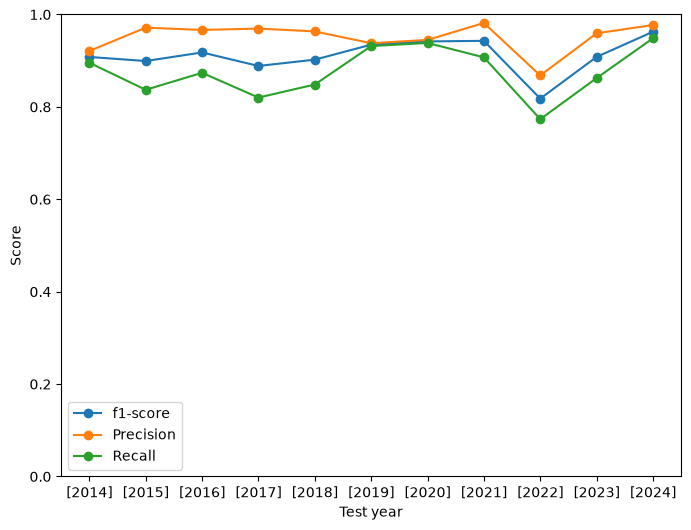

In [3]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(8,6))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [10]:
df_feature = pd.read_csv('df_imp.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Feature,,,,,,,,,,,,
co2_dry,0.003122,0.017058,0.023112,1.285998e-02,0.005851,0.003645,0.001587,0.001627,0.001798,0.001384,0.000848,0.001174
co2_wet,0.004416,0.012792,0.017542,1.711496e-03,0.003288,0.002568,0.001220,0.000637,0.001629,0.000536,0.000675,0.001161
co2_target_error,0.001046,0.000463,0.000426,1.194921e-03,0.002461,0.004368,0.003388,0.004142,0.005307,0.001432,0.000683,0.000099
co2_Cdrift,0.004373,0.002189,0.001773,3.692526e-03,0.001859,0.001025,0.001090,0.000506,0.001373,0.001388,0.000427,0.001159
co2_Nfiltered,0.000565,0.000515,0.000288,3.179306e-03,0.002889,0.004333,0.004172,0.001507,0.001485,0.003973,0.001076,0.001333
...,...,...,...,...,...,...,...,...,...,...,...,...
co2_target_error_5min_zcore_res_gen,0.010223,0.000655,0.000206,5.726950e-07,0.005126,0.003054,0.001177,0.000427,0.002072,0.002267,0.000738,0.000614
co2_target_error_per_rank_60s,0.003144,0.005767,0.002123,5.783950e-03,0.001828,0.000843,0.000063,0.001514,0.002962,0.003340,0.000184,0.000007
co2_target_error_per_rank_5min,0.000997,0.006661,0.019915,8.483261e-03,0.008442,0.007537,0.010681,0.009108,0.010798,0.017891,0.006314,0.005672


In [12]:

rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
time_since_switch                      12
cycle_time_residual_60s                11
cycle_time_diff_1                      11
cycle_time_diff_2                      11
cycle_time_roll_std_5min               11
                                       ..
co2_target_error_5min_zcore_res_gen     0
co2_target_error_per_rank_60s           0
co2_target_error_per_rank_5min          0
co2_Cdrift_per_rank_60s                 0
co2_Cdrift_per_rank_5min                0
Length: 68, dtype: int64


In [13]:
import seaborn as sns

<Axes: ylabel='Feature'>

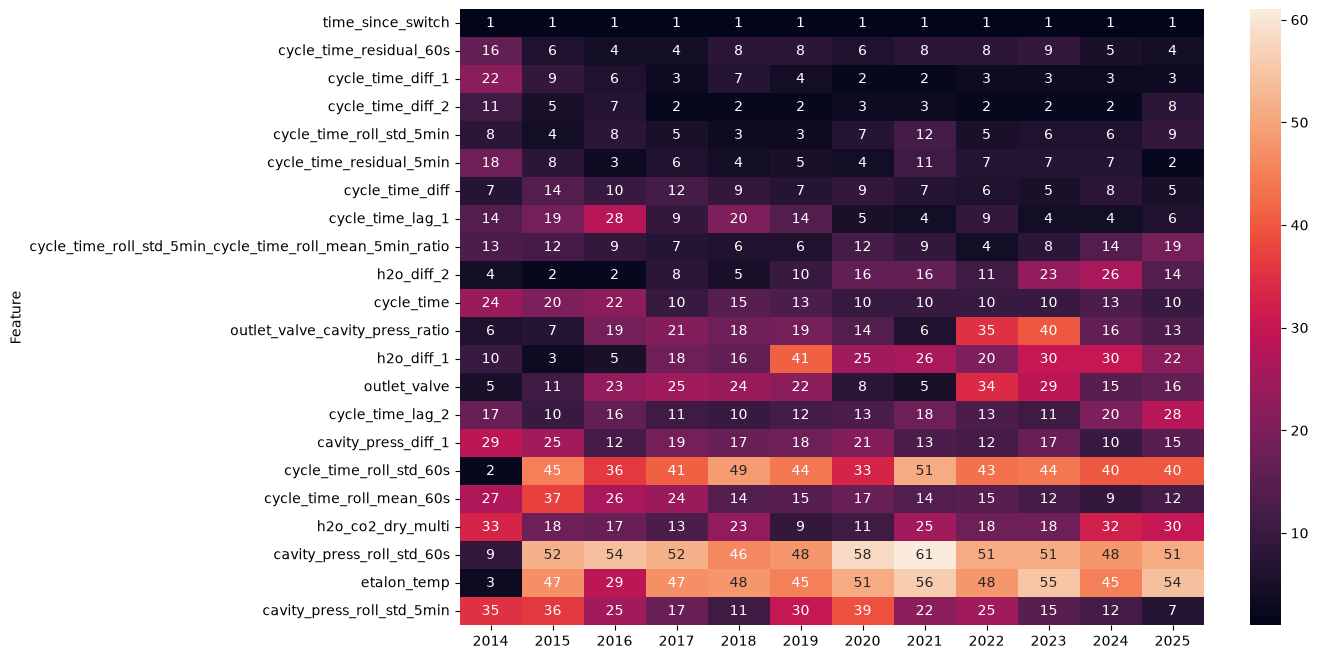

In [14]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(12,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)

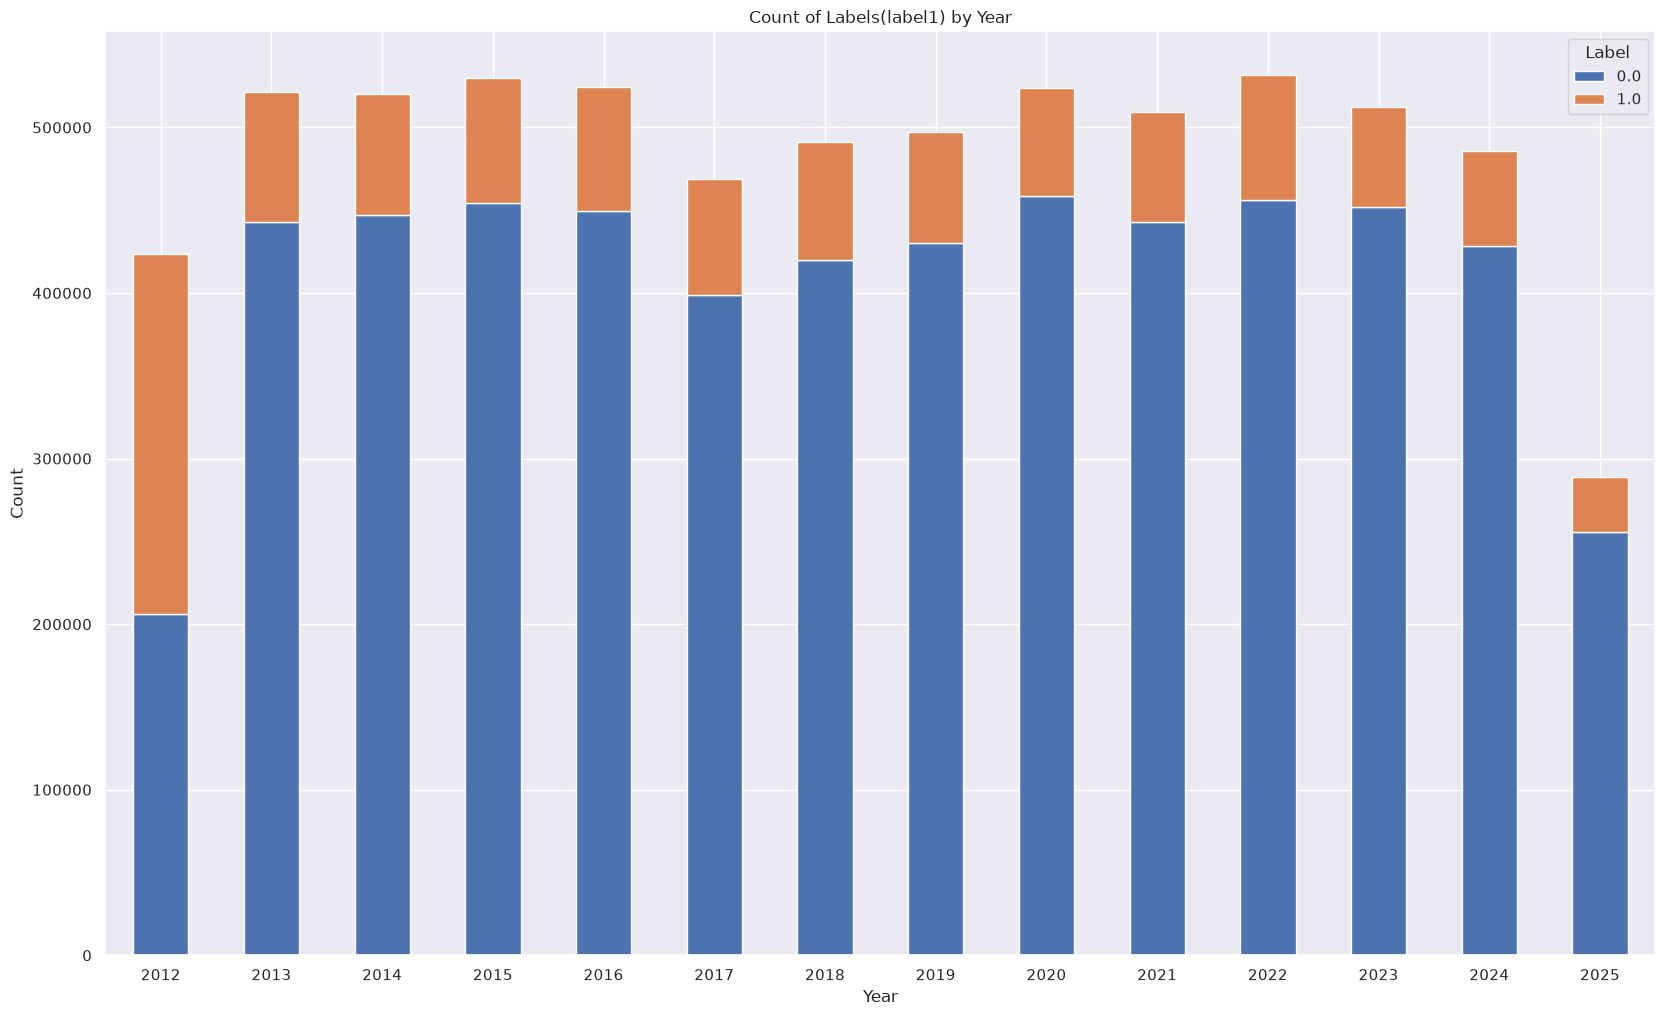

In [39]:
df = pd.read_csv('final_paper_table_2_1.csv')
df = df[:-1]
df

,Unnamed: 0,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size,Training_Year,Test Year
0,0,2012_2013,[2014],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9210,0.539047,0.879316,0.901197,0.858473,0.161330,944555.0,519970.0,NaN,NaN
1,1,2013_2014,[2015],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9055,0.721981,0.906469,0.982150,0.841618,0.540715,1041192.0,530021.0,NaN,NaN
2,2,2014_2015,[2016],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9416,0.760674,0.905273,0.976071,0.844051,0.067889,1049991.0,524543.0,NaN,NaN
3,3,2015_2016,[2017],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8960,0.734186,0.844927,0.967242,0.750075,0.226587,1054564.0,468913.0,NaN,NaN
4,4,2016_2017,[2018],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9788,0.522528,0.932702,0.936309,0.929123,-0.018920,993456.0,491374.0,NaN,NaN
5,5,2017_2018,[2019],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9669,0.702560,0.947730,0.968568,0.927770,-0.028149,960287.0,497246.0,NaN,NaN
6,6,2018_2019,[2020],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9822,0.649835,0.956501,0.976626,0.937188,-0.011156,988620.0,524057.0,NaN,NaN
7,7,2019_2020,[2021],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9685,0.628677,0.942429,0.978268,0.909124,0.008894,1021303.0,509384.0,NaN,NaN
8,8,2020_2021,[2022],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8478,0.784301,0.760691,0.700611,0.832042,0.435916,1033441.0,531485.0,NaN,NaN
9,9,2021_2022,[2023],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9032,0.711020,0.869680,0.869320,0.870041,0.170110,1040869.0,512423.0,NaN,NaN


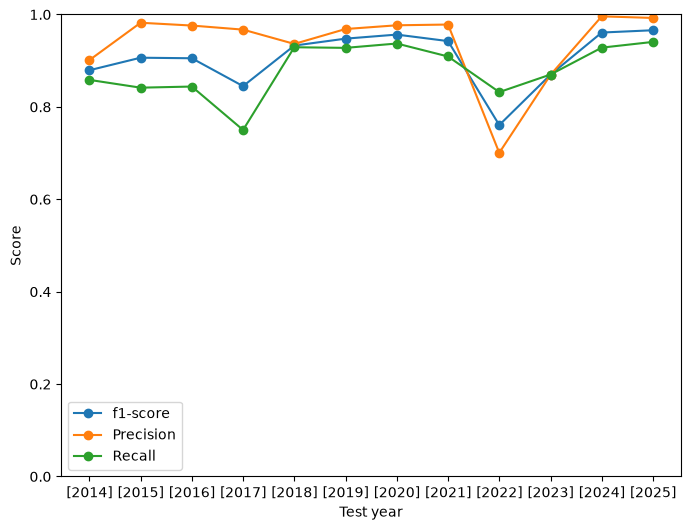

In [40]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(8,6))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()